In [2]:
import pandas as pd
import numpy as np

In [3]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")
df_usa_agr_numeric.head()

,Average Temperature (C),CO2 Emissions (MT),Crop Yield (MT per HA),Extreme Weather Events,Pesticide Use (KG per HA),Fertilizer Use (KG per HA),Economic Impact (Million USD)
8968,17.19,10.73,2.180,5,26.06,71.56,353.16
8969,14.70,11.45,2.500,9,19.48,46.13,1126.27
8970,12.03,3.86,2.450,8,13.10,2.56,1026.35
8971,12.18,19.10,1.872,8,43.15,22.46,925.79
8972,30.62,29.28,3.249,9,5.80,49.85,509.77


In [4]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008


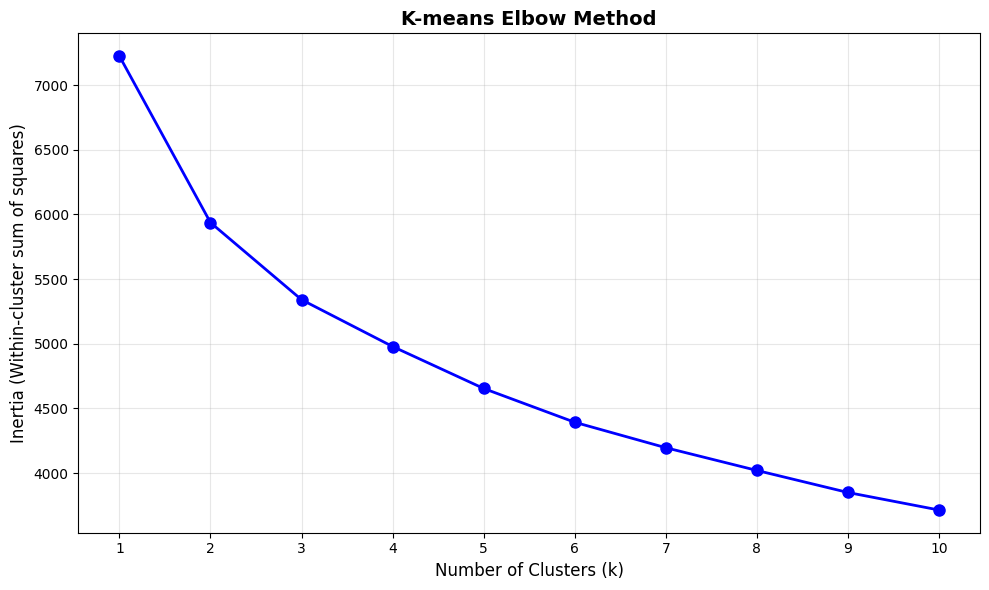

k=1: inertia=7224.00
k=2: inertia=5936.70
k=3: inertia=5340.50
k=4: inertia=4978.62
k=5: inertia=4654.16
k=6: inertia=4392.97
k=7: inertia=4196.24
k=8: inertia=4020.54
k=9: inertia=3850.10
k=10: inertia=3714.57


In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardize the features (important for K-means)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_usa_agr_numeric)

# Calculate inertia for different numbers of clusters
inertias = []
silhouette_scores = []
K_range = range(1, 11)  # Test k from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('K-means Elbow Method', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

# Print inertia values for reference
for k, inertia in zip(K_range, inertias):
    print(f"k={k}: inertia={inertia:.2f}")

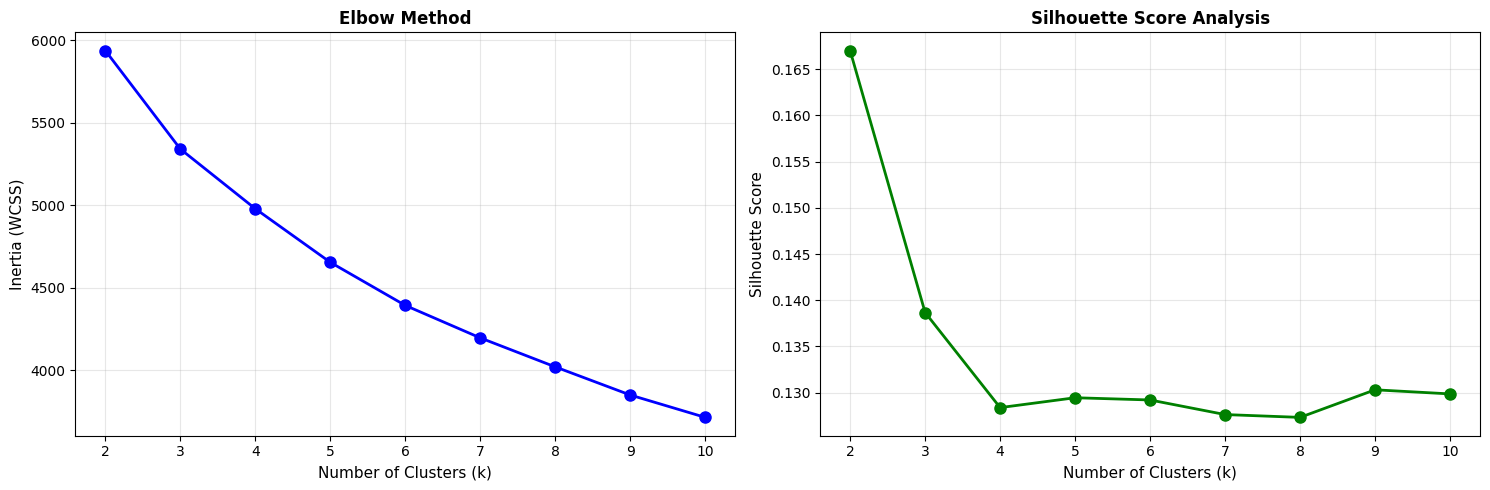

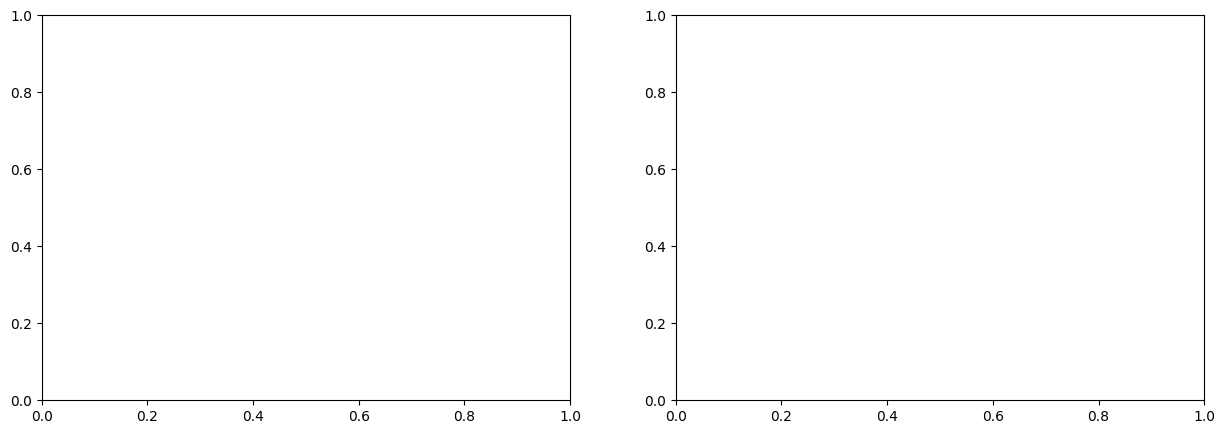

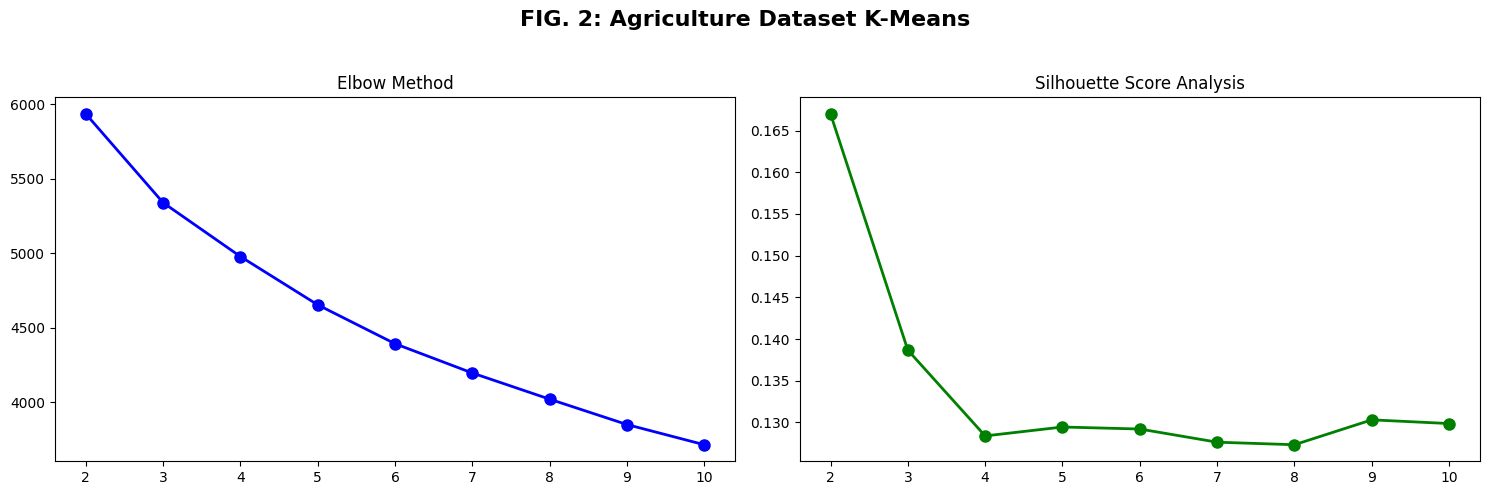


K-Means Clustering Analysis
k     Inertia         Silhouette Score
--------------------------------------------------
2     5936.70         0.1670         
3     5340.50         0.1387         
4     4978.62         0.1284         
5     4654.16         0.1295         
6     4392.97         0.1292         
7     4196.24         0.1276         
8     4020.54         0.1273         
9     3850.10         0.1303         
10    3714.57         0.1299         

Optimal k (by Silhouette Score): 2
Silhouette Score: 0.1670

Interpretation Guide:
- Silhouette Score ranges from -1 to 1
  • Closer to 1: Well-defined clusters
  • Around 0: Overlapping clusters
  • Negative: Points may be in wrong cluster
- Look for the k with the highest silhouette score


In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

# Standardize the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_usa_agr_numeric)

# Calculate metrics for different numbers of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, cluster_labels))

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plt.title("Agriculture Dataset K-Means")

# Elbow plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range)

# Silhouette plot
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(K_range)

plt.tight_layout()
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Main title
fig.suptitle("FIG. 2: Agriculture Dataset K-Means", fontsize=16, fontweight='bold')

# Elbow plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow Method')

# Silhouette plot
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score Analysis')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
# Print results
print("\nK-Means Clustering Analysis")
print("=" * 50)
print(f"{'k':<5} {'Inertia':<15} {'Silhouette Score':<15}")
print("-" * 50)
for k, inertia, silhouette in zip(K_range, inertias, silhouette_scores):
    print(f"{k:<5} {inertia:<15.2f} {silhouette:<15.4f}")

# Find optimal k based on silhouette score
optimal_k = K_range[np.argmax(silhouette_scores)]
optimal_silhouette = max(silhouette_scores)
print("\n" + "=" * 50)
print(f"Optimal k (by Silhouette Score): {optimal_k}")
print(f"Silhouette Score: {optimal_silhouette:.4f}")
print("=" * 50)

# Interpretation guide
print("\nInterpretation Guide:")
print("- Silhouette Score ranges from -1 to 1")
print("  • Closer to 1: Well-defined clusters")
print("  • Around 0: Overlapping clusters")
print("  • Negative: Points may be in wrong cluster")
print("- Look for the k with the highest silhouette score")